# Time Series and Machine Learning Excersice

Here we have a dataframe that has the sell values of several products and stores. The time comes from 2010 to 2018 and training is 2019


### Preprocessing

In [69]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('tseries_train.csv')
test = pd.read_csv('test.csv')  
train.head()

,Date,store,product,number_sold
0,2010-01-01,0,0,801
1,2010-01-02,0,0,810
2,2010-01-03,0,0,818
3,2010-01-04,0,0,796
4,2010-01-05,0,0,808


In [70]:
#we generate a summary of the dataframe , including unique store values, missing values and data types
train.info()
a=train['store'].nunique()
test['store'].nunique()
b=train['product'].nunique()
print(a*b)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230090 entries, 0 to 230089
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Date         230090 non-null  object
 1   store        230090 non-null  int64 
 2   product      230090 non-null  int64 
 3   number_sold  230090 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.0+ MB
70


From this first analysis: we can see that he have 7 stores and 10 different products. 

We can start our first approach by only modelling the different products ammong all stores

In [71]:
products=train['product'].unique()
for i in products:
    data_train=train[train['product']==i]
    data_test=test[test['product']==i]
    exec(f'product_{i} = pd.DataFrame(data_train)')
    exec(f'product_test_{i} = pd.DataFrame(data_test)')

In [72]:
product_1.head()

,Date,store,product,number_sold
3287,2010-01-01,0,1,851
3288,2010-01-02,0,1,843
3289,2010-01-03,0,1,847
3290,2010-01-04,0,1,855
3291,2010-01-05,0,1,866


Here there are 7 entries per date refeiring to the stores, so we need to add the store values that are on the same date


In [73]:
prodsdf=[product_0,product_1,product_2,product_3,product_4,product_5,product_6,product_7,product_8,product_9]
for idx, i in enumerate(prodsdf):
    m = i.groupby('Date')['number_sold'].sum().reset_index()
    exec(f'product_{idx} = pd.DataFrame(m)')
#we do the same for the test data
testprodsdf=[product_test_0,product_test_1,product_test_2,product_test_3,product_test_4,product_test_5,product_test_6,product_test_7,product_test_8,product_test_9]
for idx, i in enumerate(testprodsdf):
    m = i.groupby('Date')['number_sold'].sum().reset_index()
    exec(f'product_test_{idx} = pd.DataFrame(m)')

In [74]:
product_1.head()

,Date,number_sold
0,2010-01-01,5825
1,2010-01-02,5847
2,2010-01-03,5809
3,2010-01-04,5789
4,2010-01-05,5669


Now we can plot the 10 timeseries to visualize the data

### Products among all stores

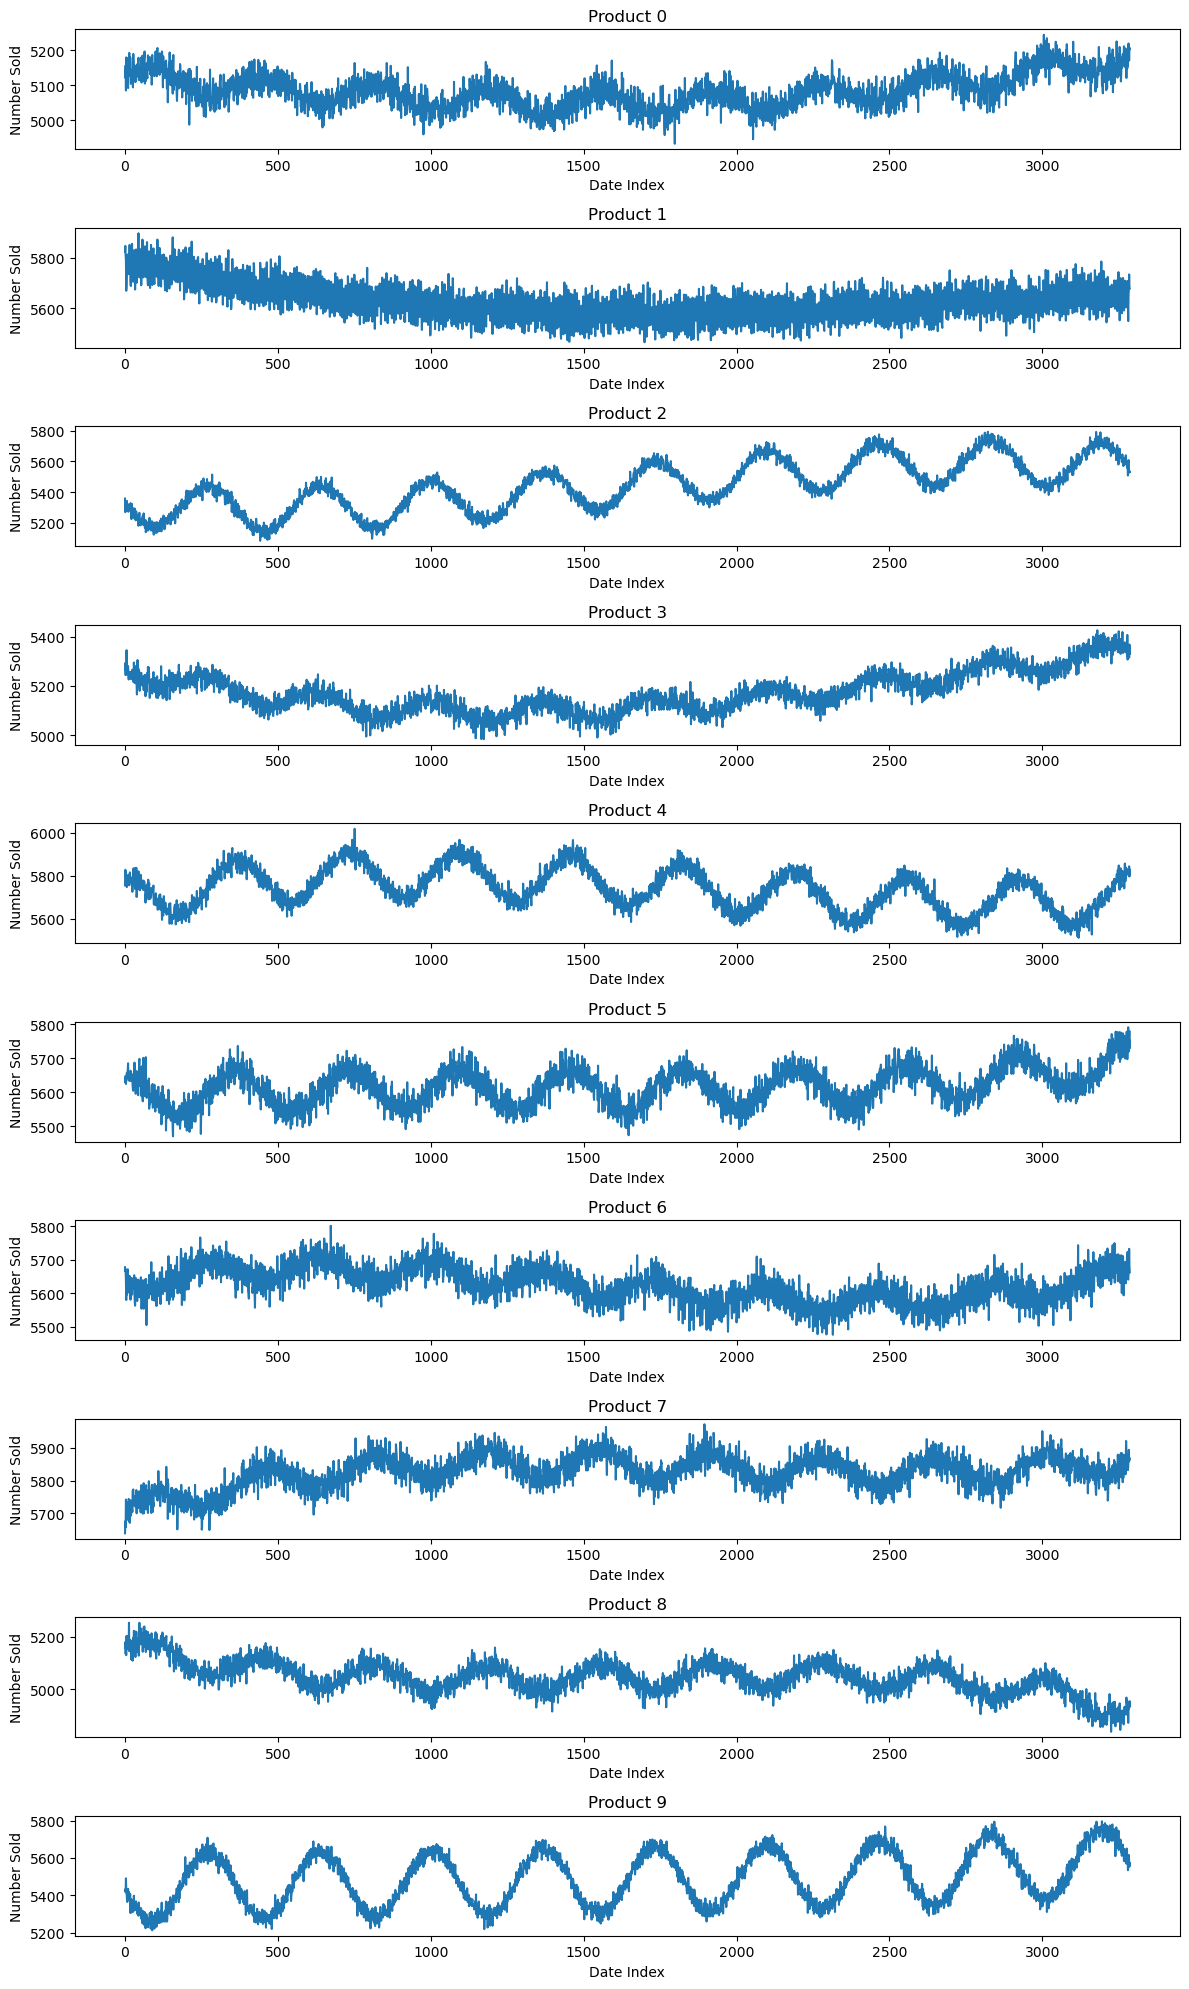

In [75]:
fig, axes = plt.subplots(10, 1, figsize=(12, 20))

for idx in range(10):
    product_df = eval(f'product_{idx}')
    axes[idx].plot(product_df['number_sold'])
    axes[idx].set_title(f'Product {idx}')
    axes[idx].set_xlabel('Date Index')
    axes[idx].set_ylabel('Number Sold')

plt.tight_layout()
plt.show()

We can see seasonality in all products except product 1. 

### Product 1:A trendline using moving average, Several regression algorithms

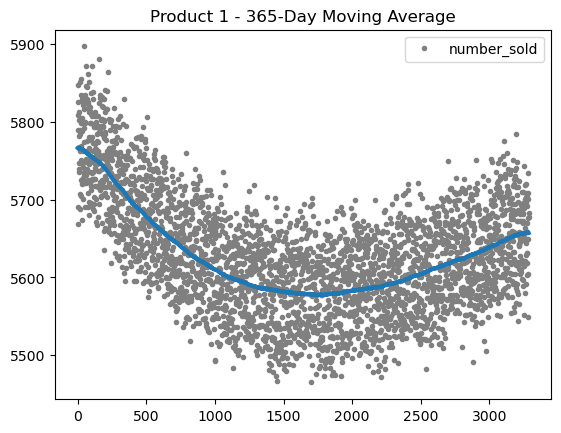

In [76]:
moving_average = product_1['number_sold'].rolling(
    window=365,       # 365-day window
    center=True,      # puts the average at the center of the window
    min_periods=183,  # choose about half the window size
).mean()              # compute the mean (could also do median, std, min, max, ...)

ax = product_1.plot(style=".", color="0.5")
moving_average.plot(
    ax=ax, linewidth=3, title="Product 1 - 365-Day Moving Average", legend=False,
);

This looks like a combination of several polynomials, so we will use spline transformer + linear regression

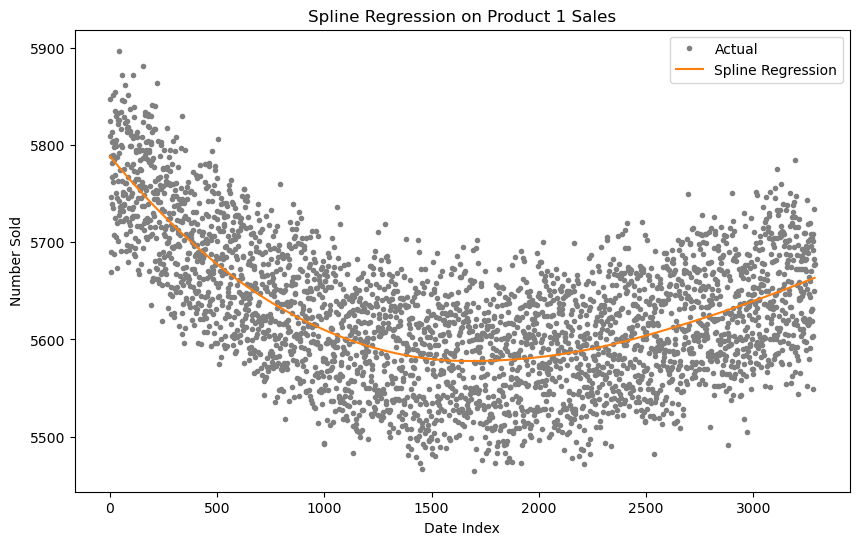

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("spline", SplineTransformer(
        n_knots=5,
        degree=2,
        include_bias=False,
        extrapolation='continue'
    )),
    ("lr", LinearRegression())
])
X=np.arange(len(product_1)).reshape(-1, 1)
y=product_1['number_sold']

model.fit(X, y)
y_pred = model.predict(X)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(X, y, label='Actual', marker='.', linestyle='None', color='0.5')
plt.plot(X, y_pred, label='Spline Regression', color='C1')
plt.title('Spline Regression on Product 1 Sales')
plt.xlabel('Date Index')
plt.ylabel('Number Sold')
plt.legend()
plt.show()



Here we can evaluate the accuracy using the test dataset

In [78]:
print(X)

[[   0]
 [   1]
 [   2]
 ...
 [3284]
 [3285]
 [3286]]


In [79]:
product_test_1.head()
#we need to set the date index to continue straight from the training data
X_test =np.arange(len(product_1), len(product_1) + len(product_test_1)).reshape(-1, 1)
y_test_pred = model.predict(X_test)


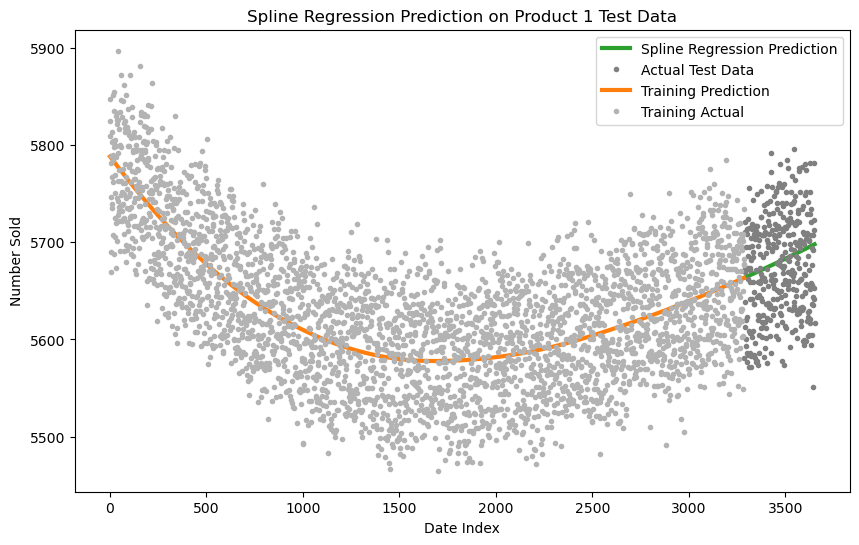

In [80]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_test_pred, label='Spline Regression Prediction', color='C2', linewidth=3)
plt.plot(X_test, product_test_1['number_sold'], label='Actual Test Data', marker='.', linestyle='None', color='0.5')
plt.plot(X, y_pred, label='Training Prediction', color='C1', linewidth=3)
plt.plot(X, y, label='Training Actual', marker='.', linestyle='None', color='0.7')
plt.title('Spline Regression Prediction on Product 1 Test Data')
plt.xlabel('Date Index')
plt.ylabel('Number Sold')
plt.legend()
plt.show()

In [81]:
#lets see the error metrics of our test and train predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y, y_pred)
train_mse = mean_squared_error(y, y_pred)
test_mae = mean_absolute_error(product_test_1['number_sold'], y_test_pred)
test_mse = mean_squared_error(product_test_1['number_sold'], y_test_pred)
train_r2 = r2_score(y, y_pred)
test_r2 = r2_score(product_test_1['number_sold'], y_test_pred)
print(f'Train MAE: {train_mae}, Train MSE: {train_mse}, Train R2: {train_r2}')
print(f'Test MAE: {test_mae}, Test MSE: {test_mse}, Test R2: {test_r2}')



Train MAE: 43.88407239219934, Train MSE: 2706.669389861061, Train R2: 0.4959121648727718
Test MAE: 44.10382494413826, Test MSE: 2708.4308723543677, Test R2: 0.011686462381242269


This is not the best model. Although it represents the trend of the whole plot, the variance from entry to entry might be too high. 
Here we can use:
#### Spline Quantile Regression Model

Overview
Spline Quantile Regression extends standard regression by estimating **conditional quantiles** of the target variable instead of only the conditional mean.  
This allows the model to produce **upper and lower amplitude boundaries** (prediction bands) that vary smoothly over the input domain.

The model combines:
- **Spline basis functions** to capture smooth, non-linear trends
- **Quantile regression** to estimate different parts of the response distribution

---

 Model Structure

Given an input variable \( x \) (e.g., time index), the model is:

\[
Q_y(\tau \mid x) = \beta_0 + \sum_{j=1}^{K} \beta_j B_j(x)
\]

Where:
- \( Q_y(\tau \mid x) \) is the conditional quantile at level \( \tau \)
- \( B_j(x) \) are spline basis functions
- \( \beta_j \) are learned coefficients
- \( \tau \in (0, 1) \) defines the quantile (e.g. 0.1, 0.5, 0.9)

Each quantile is fit **independently**, producing a smooth curve.

---

 Components

 1. Spline Transformation
The spline transformer:
- Divides the input space into intervals using **knots**
- Fits low-degree (usually cubic) polynomials in each interval
- Enforces smoothness at knot boundaries

This allows the curvature of the regression function to change over time.

 2. Quantile Regression
Quantile regression:
- Minimizes the **pinball loss** instead of squared error
- Estimates conditional quantiles directly
- Is robust to outliers and heteroskedasticity

---

 Interpretation

By fitting multiple quantiles:
- \( \tau = 0.5 \) → median trend (central curve)
- \( \tau = 0.1 \) → lower amplitude boundary
- \( \tau = 0.9 \) → upper amplitude boundary

The area between the lower and upper curves forms a **prediction band** that adapts to changes in variability over time.


In [82]:

from sklearn.linear_model import QuantileRegressor

def spline_quantile_model(q):
    return Pipeline([
        ("spline", SplineTransformer(
            n_knots=8,
            degree=3,
            include_bias=False,
            extrapolation='linear'
        )),
        ("qr", QuantileRegressor(
            quantile=q,
            alpha=0.0000000,   # no regularization initially
            solver="highs"
        ))
    ])

#lower = spline_quantile_model(0.1)
median = spline_quantile_model(0.5)
#upper = spline_quantile_model(0.9)

#lower.fit(X, y)
median.fit(X, y)
#upper.fit(X, y)

#y_low = lower.predict(X)
y_mid = median.predict(X)
#y_high = upper.predict(X)

#y_test_low = lower.predict(X_test)
y_test_mid = median.predict(X_test)
#y_test_high = upper.predict(X_test)
y_hat=y_test_mid

residuals = np.abs(y - median.predict(X))

scale_model = Pipeline([
    ("spline", SplineTransformer(
        n_knots=6,
        degree=3,
        include_bias=False,
        extrapolation="linear"
    )),
    ("lr", LinearRegression())
])

scale_model.fit(X, residuals)
sigma_hat = scale_model.predict(X_test)
sigma_hat_train = scale_model.predict(X)

k = 1.6  # ≈ 80% interval

test_lower = y_hat - k * sigma_hat
test_upper = y_hat + k * sigma_hat
train_lower = y_mid - k * sigma_hat_train
train_upper = y_mid + k * sigma_hat_train

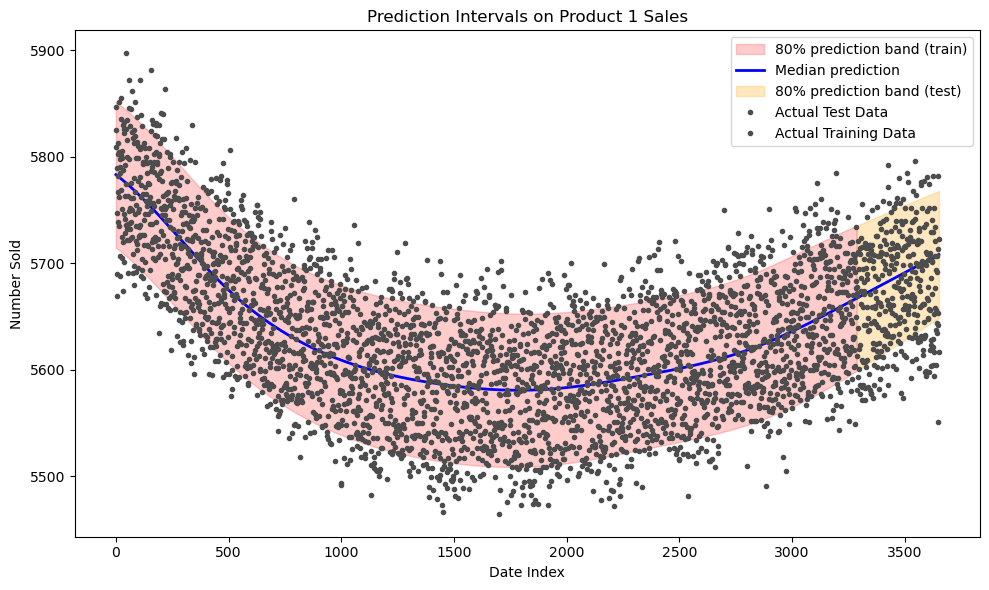

In [83]:

# --- PLOT ---
plt.figure(figsize=(10, 6))

# Training prediction band
plt.fill_between(
    X.ravel(),
    train_lower,
    train_upper,
    color="red",
    alpha=0.2,
    label="80% prediction band (train)"
)

# Training median
plt.plot(
    X,
    y_mid,
    color="blue",
    lw=2,
    label="Median prediction"
)

# Test prediction band
plt.fill_between(
    X_test.ravel(),
    test_lower,
    test_upper,
    color="orange",
    alpha=0.25,
    label="80% prediction band (test)"
)

# Test median
plt.plot(
    X_test,
    y_test_mid,
    color="blue",
    lw=2
)
plt.plot(X_test, product_test_1['number_sold'], label='Actual Test Data', marker='.', linestyle='None', color='0.3')
plt.plot(X,y, label='Actual Training Data', marker='.', linestyle='None', color='0.3')
plt.title("Prediction Intervals on Product 1 Sales")
plt.xlabel("Date Index")
plt.ylabel("Number Sold")
plt.legend()
plt.tight_layout()
plt.show()


Here we evaluate the accuracy of the model

1. PICP, (Prediction Interval Coverage Probability): Measures reliability. You want this to match your target (0.80).
2. MPIW (Mean Prediction Interval Width): Measures "Sharpness." If two models both have 80% coverage, the one with the smaller MPIW is better.
3. ACE (Average Coverage Error): Simply $PICP - Target$. A negative value means you are under-covering (your current case).

In [84]:

# 1. PICP (Coverage)
covered = (product_test_1['number_sold'] >= test_lower) & (product_test_1['number_sold'] <= test_upper)
picp = np.mean(covered)

# 2. MPIW (Width)
mpiw = np.mean(test_upper - test_lower)

# 3. Simple Out-of-Bounds Score (ACE)
# Average Coverage Error: How far off is your coverage from the 80% target?
ace = picp - 0.80

print(f"Coverage (PICP): {picp:.2%}")
print(f"Average Width (MPIW): {mpiw:.2f}")
print(f"Calibration Error (ACE): {ace:.2%}")

Coverage (PICP): 73.70%
Average Width (MPIW): 127.78
Calibration Error (ACE): -6.30%


We have a 73.7% coverage , close ennough to the 80% target

### Products 0,2,3,4,5,6,7,8,9 Seasonality analysis

<Axes: title={'center': 'Periodogram'}, ylabel='Variance'>

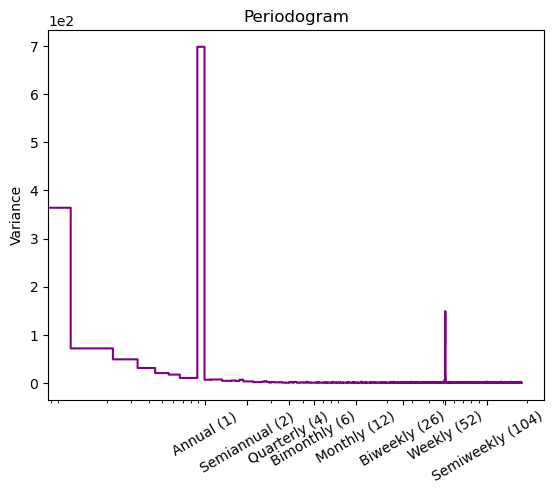

In [85]:
#Lets use product 6 as an example
#We need to do a periodgram of the data to see the frequency components



# annotations: https://stackoverflow.com/a/49238256/5769929
def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors=X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )
    return ax


def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

plot_periodogram(product_6['number_sold'])


Here we see a clear yearly period, with an almost discrete form. 

Lets take into account the months then (12 Fourier Pairs)


c:\Users\santi\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


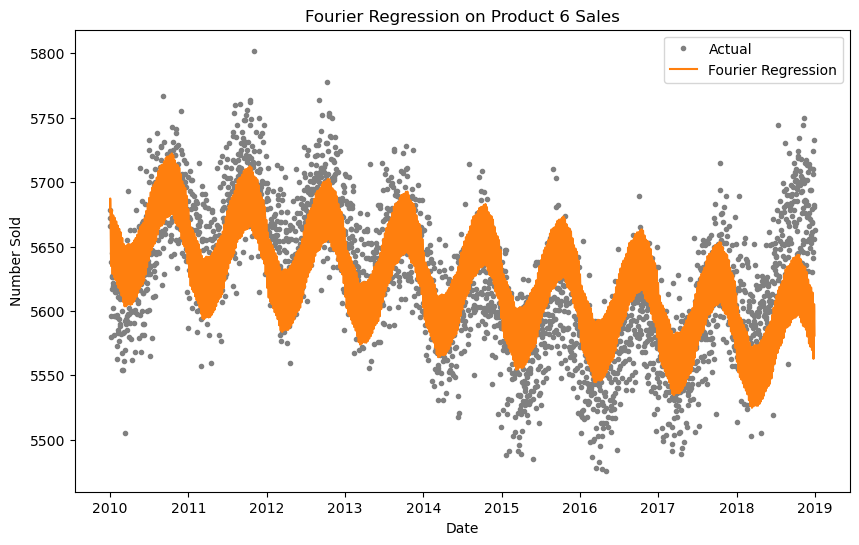

In [86]:
#12 fourier pairs
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

# Prepare product_6 data with proper date index
product_6_data = product_6.copy()
product_6_data['Date'] = pd.to_datetime(product_6_data['Date'])
product_6_data.set_index('Date', inplace=True)

fourier = CalendarFourier(freq="A", order=12)
dp = DeterministicProcess(
    index=product_6_data.index,
    constant=True,               # dummy feature for bias (intercept)
    order=1,                     # trend (linear)
    seasonal=True,               # yearly seasonality (dummy variables)
    additional_terms=[fourier],  # fourier terms
    drop=True,                   # drop terms to avoid collinearity
) 
X = dp.in_sample()
y = product_6_data['number_sold']
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
y_pred = model.predict(X)
plt.figure(figsize=(10, 6))
plt.plot(product_6_data.index, y, label='Actual', marker='.', linestyle='None', color='0.5')
plt.plot(product_6_data.index, y_pred, label='Fourier Regression', color='C1')
plt.title('Fourier Regression on Product 6 Sales')
plt.xlabel('Date')
plt.ylabel('Number Sold')
plt.legend()
plt.show()



In [87]:
# 1. Prepare training data with a frequency
product_6_data = product_6.copy()
product_6_data['Date'] = pd.to_datetime(product_6_data['Date'])
product_6_data.set_index('Date', inplace=True)
# Set the frequency (assuming daily data). This is the crucial step.
product_6_data = product_6_data.asfreq('D') 
product_6_data['number_sold'] = product_6_data['number_sold'].fillna(0) # Fill gaps if any

# 2. Define the process
fourier = CalendarFourier(freq="A", order=12)
dp = DeterministicProcess(
    index=product_6_data.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier],
    drop=True,
) 

X = dp.in_sample()
y = product_6_data['number_sold']
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

c:\Users\santi\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


LinearRegression(fit_intercept=False)

In [88]:
product_test_6 = product_test_6.copy()
product_test_6['Date'] = pd.to_datetime(product_test_6['Date'])
product_test_6.set_index('Date', inplace=True)
product_test_6 = product_test_6.asfreq('D')
product_test_6['number_sold'] = product_test_6['number_sold'].fillna(0)
product_test_6.head()

,number_sold
Date,
2019-01-01,5659
2019-01-02,5647
2019-01-03,5699
2019-01-04,5636
2019-01-05,5645


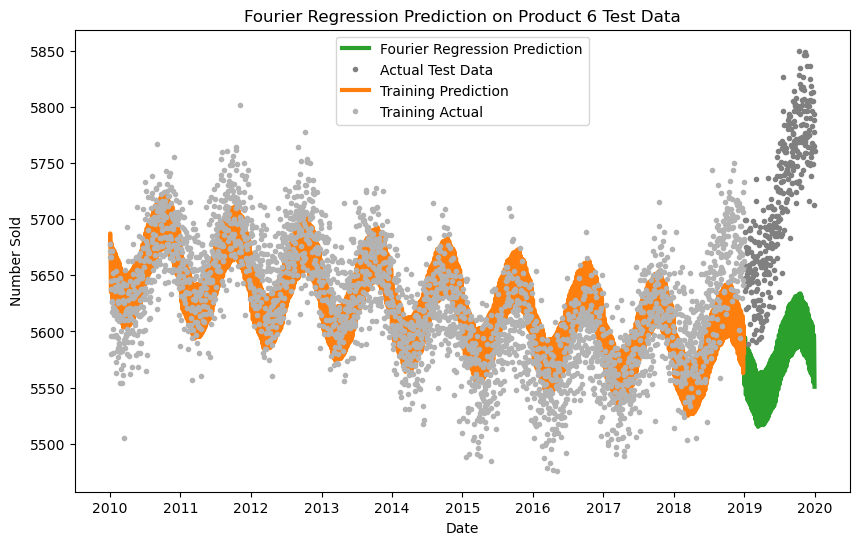

In [89]:
X_test = dp.out_of_sample(steps=len(product_test_6))
y_test_pred = model.predict(X_test)
plt.figure(figsize=(10, 6))
plt.plot(product_test_6.index, y_test_pred, label='Fourier Regression Prediction', color='C2', linewidth=3)
plt.plot(product_test_6.index, product_test_6['number_sold'], label='Actual Test Data', marker='.', linestyle='None', color='0.5')
plt.plot(product_6_data.index, y_pred, label='Training Prediction', color='C1', linewidth=3)
plt.plot(product_6_data.index, y, label='Training Actual', marker='.', linestyle='None', color='0.7')
plt.title('Fourier Regression Prediction on Product 6 Test Data')
plt.xlabel('Date')
plt.ylabel('Number Sold')
plt.legend()
plt.show()

In [90]:

# 2. Create lag -2 (t-2)
product_6_data['number_sold_lag2'] = product_6_data['number_sold'].shift(2)

# 3. Define the deterministic process
fourier = CalendarFourier(freq="A", order=12)
dp = DeterministicProcess(
    index=product_6_data.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier],
    drop=True,
)

X = dp.in_sample()

# 4. Add the lagged term to X
X['number_sold_lag2'] = product_6_data['number_sold_lag2']

# 5. Drop rows with NaNs caused by the lag
X = X.dropna()
y = product_6_data.loc[X.index, 'number_sold']

# 6. Fit model
model_2 = LinearRegression(fit_intercept=False)
model_2.fit(X, y)


c:\Users\santi\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


LinearRegression(fit_intercept=False)

In [ ]:
product_test_6.head()


,number_sold
Date,
2019-01-01,5659
2019-01-02,5647
2019-01-03,5699
2019-01-04,5636
2019-01-05,5645


In [ ]:
X_test= dp.out_of_sample(steps=len(product_test_6))
